Датасет закинул на гитхаб, так как он весит очень мало. Проще так, чем оставлять ссылку.

In [160]:
import shutil
import pandas
from category_encoders import HashingEncoder

shutil.copyfile('or_test.csv', 'test.csv')

ds = pandas.read_csv('test.csv')

A)

In [ ]:
import pandas

ds = pandas.read_csv("test.csv")
original_ds = ds.copy()
ds.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [162]:
ds.tail()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
417,1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [163]:
ds.shape

(418, 11)

B)

In [164]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [165]:
ds.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [166]:
ds.describe(include="str")

,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Kelly, Mr. James",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


In [167]:
ds.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [168]:
ds.isnull().sum() / ds.shape[0] * 100

PassengerId     0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.574163
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.239234
Cabin          78.229665
Embarked        0.000000
dtype: float64

In [169]:
print("Количество полных дубликатов: ", ds.duplicated().sum())
if ds["PassengerId"].is_unique == True:
    print("ID пассажиров уникален")
else:
    print("ID пассажиров не уникален")

Количество полных дубликатов:  0
ID пассажиров уникален


B)

Для начала я бы отсеял пассажиров, которые дают мало информации. Основываясь на статистике .isnull().sum() логично будет вычеркнуть строки, в которых отсутствует 2 параметра.
aka демонстрация работы с dropna().

In [170]:
print ("Before:\n", original_ds.shape, "\n", ds.isnull().sum())
ds.dropna(thresh=9, inplace=True)
print ("\nAfter:\n", ds.shape, "\n", ds.isnull().sum())

Before:
 (418, 11) 
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

After:
 (418, 11) 
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


 Для заполнения возраста выбрал медиану, так как она более устойчива к выбросам.

In [171]:
print("Before: ", original_ds["Age"].isnull().sum())
ds["Age"] = ds["Age"].fillna(ds["Age"].median())
print("After: ", ds["Age"].isnull().sum())

Before:  86
After:  0


Для заполнения цены использовал медиану по классу места, так как цены на билеты разных классов могут сильно различаться. Если у пассажира с отсутствующей информацией о цене билета также отсутствует информация о классе, то заполняется медианой.

In [172]:
print("Before: ", original_ds["Fare"].isnull().sum())
if ds["Fare"].fillna(ds.groupby("Pclass")["Fare"].transform("median")).isnull().sum() == 0:
    ds["Fare"] = ds["Fare"].fillna(ds.groupby("Pclass")["Fare"].transform("median"))
else:
    ds["Fare"] = ds["Fare"].fillna(ds["Fare"].median())
print("Before: ", ds["Fare"].isnull().sum())

Before:  1
Before:  0


Колонку Cabin я бы удалил, так как в ней отсутствует информация о 78% пассажиров, как показано выше. Но в ТЗ сказано показать заполнение категориальных колонок модой. Поэтому я в копии датасета заполню модой, после чего удалю эту колонку в рабочем датасете.

In [173]:
print("Before: ", original_ds["Cabin"].isnull().sum())
ds1 = ds.copy()
ds1["Cabin"] = ds1["Cabin"].fillna(ds["Cabin"].mode()[0])
print("After: ", ds1["Cabin"].isnull().sum())
del ds1

Before:  327
After:  0


Как видно из статистики ниже, пропуски остались только в столбце Cabin, причем их очень много. Поэтоу удаляем все столбцы, в которых есть пропуски. Таким будет только столбец Cabin.

In [174]:
print ("Before:\n", original_ds.columns.to_list())
ds.dropna(axis=1, inplace=True)
print ("After:\n", ds.columns.to_list())

Before:
 ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
After:
 ['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


C)

In [175]:
num_ds = ds.select_dtypes(include=['number'])
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]
statistics = ["5%", "25%", "50%", "75%", "95%", "min", "max", "mean"]
statistics = num_ds.describe(percentiles=percentiles).loc[statistics]
statistics.loc["median"] = statistics.loc["50%"]
statistics.loc["mode"] = num_ds.mode().iloc[0]
statistics

,PassengerId,Pclass,Age,SibSp,Parch,Fare
5%,912.85,1.00000,10.000000,0.000000,0.000000,7.229200
25%,996.25,1.00000,23.000000,0.000000,0.000000,7.895800
50%,1100.50,3.00000,27.000000,0.000000,0.000000,14.454200
75%,1204.75,3.00000,35.750000,1.000000,0.000000,31.471875
95%,1288.15,3.00000,55.000000,2.000000,2.000000,151.550000
min,892.00,1.00000,0.170000,0.000000,0.000000,0.000000
max,1309.00,3.00000,76.000000,8.000000,9.000000,512.329200
mean,1100.50,2.26555,29.599282,0.447368,0.392344,35.560845
median,1100.50,3.00000,27.000000,0.000000,0.000000,14.454200
mode,892.00,3.00000,27.000000,0.000000,0.000000,7.750000


Дисперсия - насколько данные в датасете отличаются от среднего. Средний квадрат отклонений.
Ассиметрия - в какую сторону завален график. Может показать, что много маленьких и мало больших значений и наоборот.
Эксцесс - показывает, насколько часто встречаются аномальные значения. На графике это длинные хвосты.

Для моих данных: 
Дисперсия цены довольно высокая, что значит, что цены билетов могли сильно различаться.
Ассиметрия Sibsp и Parch ~4, что значит, что большинство пассажиров были одни, но попадались редкие случаи очень большиз семей. Ассиметрия цены билета 3.7, что значит, что было много дешевых билетов и немного дорогих.
Большой эксцесс SibSp, Parch и Fare говорит о том, что в этих характеристиках почти все значения одинаковые, но есть редкие далекие значения.

In [176]:
statistics = pandas.DataFrame(columns=num_ds.columns)
statistics.loc['variance'] = num_ds.var()      # Дисперсия
statistics.loc['skewness'] = num_ds.skew()     # Асимметрия
statistics.loc['kurtosis'] = num_ds.kurt()     # Эксцесс
statistics

,PassengerId,Pclass,Age,SibSp,Parch,Fare
variance,14595.166667,0.708690,161.385768,0.804178,0.963203,3120.001278
skewness,0.000000,-0.534170,0.660747,4.168337,4.654462,3.691621
kurtosis,-1.200000,-1.382666,0.923988,26.498712,31.412513,17.964362


D)

In [177]:
ds = pandas.get_dummies(ds, columns=['Sex', 'Embarked'], drop_first=True)
ds

,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,True,True,False
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,False,False,True
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,True,True,False
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,True,False,True
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",27.0,0,0,A.5. 3236,8.0500,True,False,True
414,1306,1,"Oliva y Ocana, Dona. Fermina",39.0,0,0,PC 17758,108.9000,False,False,False
415,1307,3,"Saether, Mr. Simon Sivertsen",38.5,0,0,SOTON/O.Q. 3101262,7.2500,True,False,True
416,1308,3,"Ware, Mr. Frederick",27.0,0,0,359309,8.0500,True,False,True


Использовал только One Hot Encoding, потому что Target и Label применить здесь негде.

Дальше применил Feature Hashing.

In [178]:
he = HashingEncoder(cols=['Ticket'], n_components=10)
ds = he.fit_transform(ds)
ds

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,PassengerId,Pclass,Name,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,0,0,0,0,0,0,1,0,0,892,3,"Kelly, Mr. James",34.5,0,0,7.8292,True,True,False
1,1,0,0,0,0,0,0,0,0,0,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,7.0000,False,False,True
2,0,0,0,0,0,1,0,0,0,0,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,9.6875,True,True,False
3,0,0,0,0,0,0,0,0,1,0,895,3,"Wirz, Mr. Albert",27.0,0,0,8.6625,True,False,True
4,0,0,0,0,1,0,0,0,0,0,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,12.2875,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,0,0,0,0,1,0,0,0,0,0,1305,3,"Spector, Mr. Woolf",27.0,0,0,8.0500,True,False,True
414,1,0,0,0,0,0,0,0,0,0,1306,1,"Oliva y Ocana, Dona. Fermina",39.0,0,0,108.9000,False,False,False
415,0,0,0,0,1,0,0,0,0,0,1307,3,"Saether, Mr. Simon Sivertsen",38.5,0,0,7.2500,True,False,True
416,0,1,0,0,0,0,0,0,0,0,1308,3,"Ware, Mr. Frederick",27.0,0,0,8.0500,True,False,True


Столбцы с количеством братьев\сестер и с количеством родителей\детей на борту решил объеденить в один столбец с размером семьи на борту.

In [179]:
ds["FamilySize"] = ds["SibSp"] + ds["Parch"] + 1
ds.drop(["SibSp", "Parch"], axis=1, inplace=True)
ds.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,PassengerId,Pclass,Name,Age,Fare,Sex_male,Embarked_Q,Embarked_S,FamilySize
0,0,0,0,0,0,0,0,1,0,0,892,3,"Kelly, Mr. James",34.5,7.8292,True,True,False,1
1,1,0,0,0,0,0,0,0,0,0,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,7.0000,False,False,True,2
2,0,0,0,0,0,1,0,0,0,0,894,2,"Myles, Mr. Thomas Francis",62.0,9.6875,True,True,False,1
3,0,0,0,0,0,0,0,0,1,0,895,3,"Wirz, Mr. Albert",27.0,8.6625,True,False,True,1
4,0,0,0,0,1,0,0,0,0,0,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,12.2875,False,False,True,3


E)

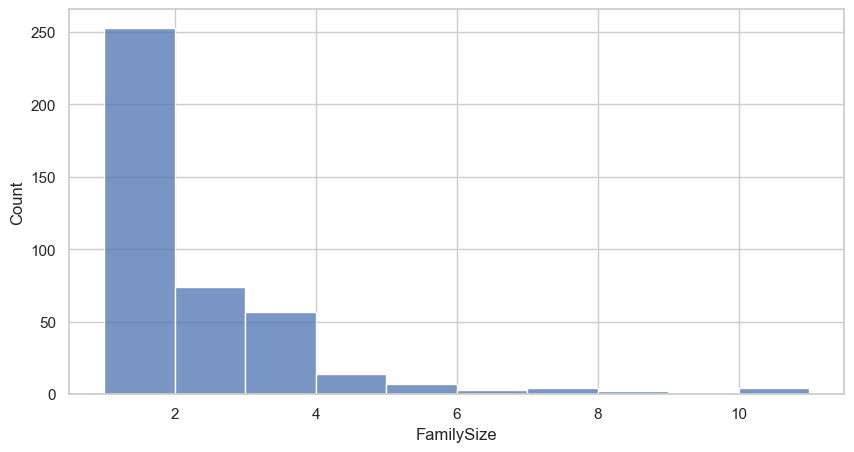

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.histplot(ds['FamilySize'].dropna(), bins=10)
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

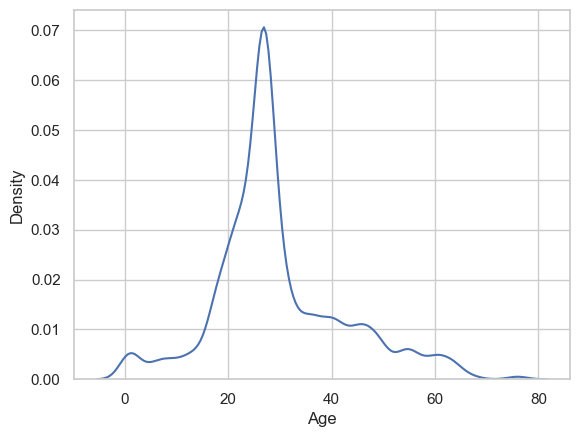

In [181]:
sns.kdeplot(ds['Age'], bw_adjust=0.5)

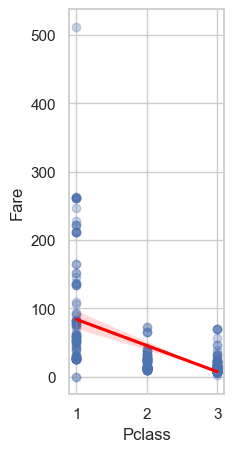

In [182]:
plt.figure(figsize=(2, 5))
sns.regplot(data=ds, x='Pclass', y='Fare', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_17064\2548546829.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ds, x='Pclass', y='Fare', palette='Set2')


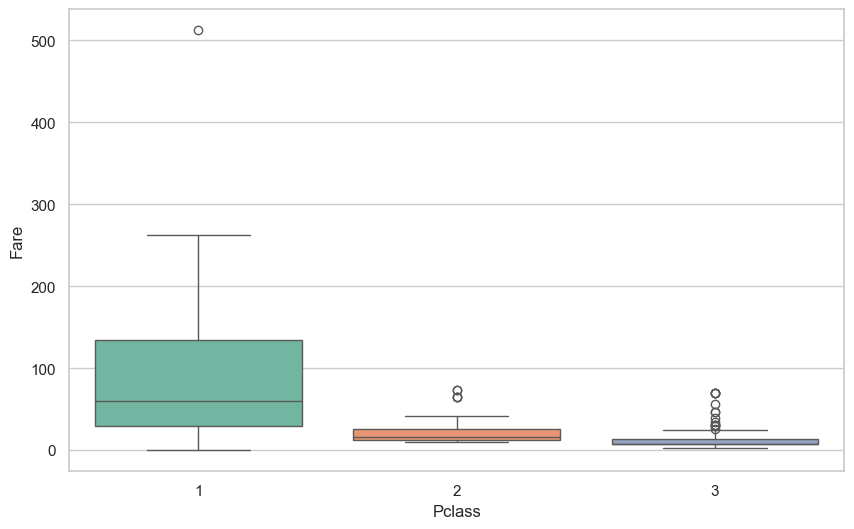

In [187]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=ds, x='Pclass', y='Fare', palette='Set2')

plt.show()

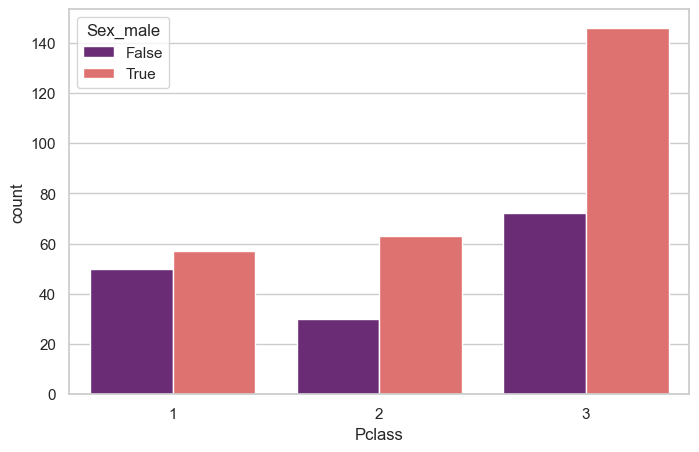

In [186]:
plt.figure(figsize=(8, 5))
sns.countplot(data=ds, x='Pclass', hue='Sex_male', palette='magma')
plt.show()

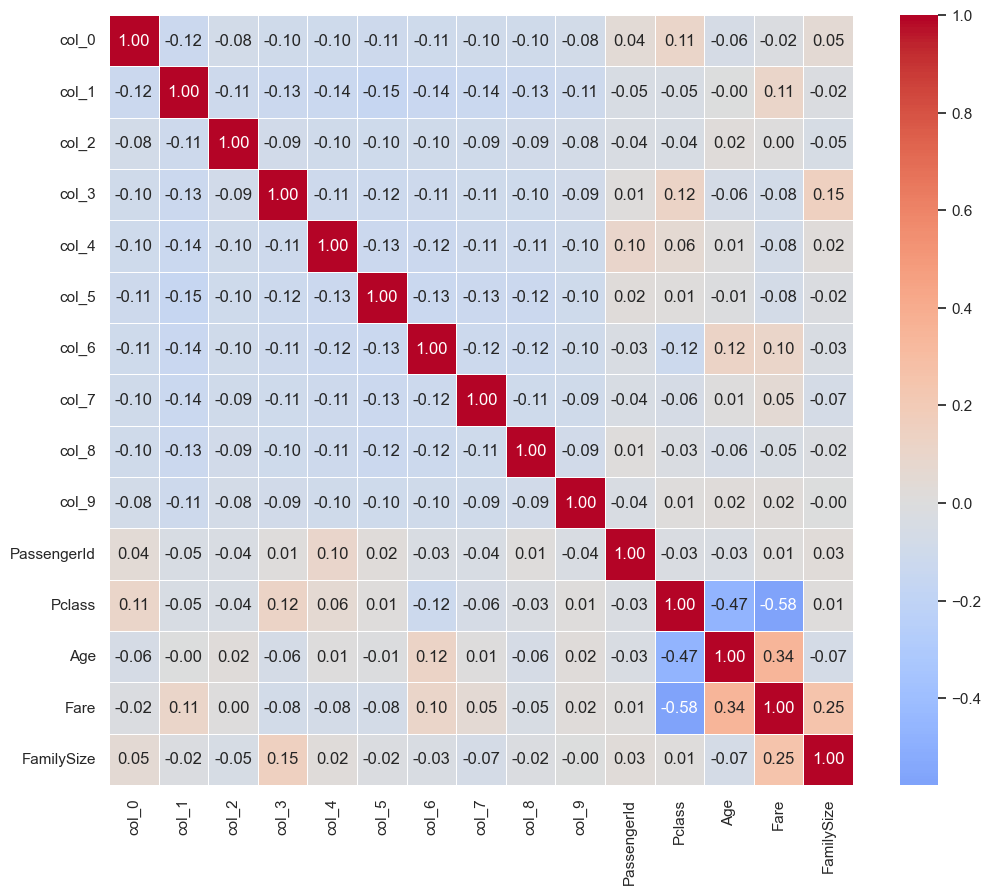

In [185]:
corr_matrix = ds.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, 
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.show()

F)


- Датасет - просто набор данных, двумерная таблица.
- Датасет может храниться в .csv файле как перечисление.
- Перед обучением модели требуется изучить датасет, выявить связи между переменными и т.д. 
- Перед обучением модели требуется подготовить датасет.
- Многие данные придется удалить или предсказать для подготовки датасета.
- Многие данные могут навредить модели, "Запутать".

- Зачастую корреляции между переменными можно объяснить, исходя из житейского опыта. То есть зачастую корреляции интуитивны.
- То же можно сказать о переменных, которые не будут как-либо помогать, а только путать модель.

Дальше я бы построил линейную модель для работы со многими переменными, а также различные модели, которые аппроксимируют графики на плоскости, и изучил поведение моделей на разных датасетах. Также изучил бы (то есть построил бы модель и "поигрался") ситуации с обработкой разных датасетов одной моделью. То есть когда в одном датасете есть одна информация, а в другом - другая, но предсказывать все равно надо. Это бы усилило навыки работы с датасетами (то есть стандартизация под одну модель).

Я впервые столкнулся с разработкой на Python и сферой ML, так что AI использовал по сути вместо браузера из-за большого потока информации. Просил разъяснить очень многие темы (чуть ли не все), спрашивал про синтаксис языка, отправлял промты для поиска отправной точки для поиска информации и т.д.